# Redes Adversariales Generativas (GANs)

Las redes adversariales generativas, conocidas como GANs, constituyen una arquitectura revolucionaria de aprendizaje profundo introducida en 2014 por [Ian Goodfellow](https://arxiv.org/pdf/1406.2661.pdf) y colaboradores. Su propósito es entrenar modelos que aprendan a sintetizar datos realistas a partir de conjuntos de entrenamiento, especialmente en la generación de imágenes. Aunque el concepto fundamental es simple, su implementación práctica presentó desafíos significativos durante años. Actualmente, estas redes producen resultados extraordinarios en múltiples aplicaciones:

- Síntesis de rostros: https://www.thispersondoesnotexist.com/
- Generación de propiedades inmobiliarias: https://thisrentaldoesnotexist.com/
- Mejora de resolución: https://www.youtube.com/watch?v=3RYNThid23g
- Restauración de imágenes a color: https://github.com/jantic/DeOldify
- Creación de escenas naturales: http://nvidia-research-mingyuliu.com/gaugan
- Y muchas aplicaciones más.

## Estructura Fundamental

Las redes GANs se organizan a través de dos componentes neuronales distintos:

- El **generador**: toma como entrada vectores de ruido aleatorio (típicamente muestreados de una distribución gaussiana) y produce como salida imágenes sintéticas. Este vector de entrada puede interpretarse como una representación comprimida o latente de la imagen generada.
- El **discriminador**: recibe imágenes como entrada (ya sean del conjunto de datos real o producidas por el generador) y realiza una clasificación binaria determinando si la imagen pertenece a la categoría real o sintética.

![](https://www.researchgate.net/publication/336781462/figure/fig2/AS:817722363494401@1571971612898/Example-of-a-typical-GANs-architecture-for-both-hand-written-digits-recognition-and.png)

Durante el proceso de aprendizaje, ambas redes entablan una competencia recíproca. El generador busca constantemente mejorar sus producciones para engañar al discriminador, mientras que el discriminador perfecciona su capacidad de discernimiento entre imágenes auténticas e imágenes fabricadas artificialmente. Este escenario competitivo requiere un procedimiento de entrenamiento especializado, diferente al empleado en redes convencionales. El objetivo es alcanzar un generador de tal calidad que el discriminador sea incapaz de distinguir entre imágenes reales y falsas. Esta condición impone restricciones rigurosas en el protocolo de entrenamiento, requiriendo un enfoque meticuloso para lograrse exitosamente.

## Procedimiento de Entrenamiento

El proceso de aprendizaje de una GAN se estructura en dos fases coordinadas:

1. **Fase del discriminador**: En cada paso iterativo, entrenamos al discriminador presentándole un lote mixto de imágenes auténticas del conjunto de datos e imágenes falsas generadas por el generador. Asignamos etiquetas binarias: 0 para las imágenes sintéticas y 1 para las auténticas. Aplicamos una función de pérdida de entropía cruzada binaria para refinar el discriminador, mejorando así su habilidad para diferenciar genuinas de fabricadas.
2. **Fase del generador**: Después, entrenamos el generador alimentándolo con vectores de ruido aleatorio para que produzca imágenes. Estas imágenes sintéticas se introducen en el discriminador, y sus predicciones (clasificación real/falso) se comparan con etiquetas que indican que las imágenes son reales. Utilizamos la misma función de pérdida para actualizar el generador, permitiendo que ajuste sus parámetros para generar imágenes cada vez más convincentes.

## Implementación: GAN Elemental con STL-10

Demostraremos cómo construir e implementar esta arquitectura junto con su procedimiento de entrenamiento usando una GAN fundamental para generar imágenes del dataset STL-10 a resolución 96x96 píxeles.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
os.makedirs('./stl10_matlab', exist_ok=True)
!cp /content/drive/MyDrive/stl10_matlab/train.mat ./stl10_matlab/

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [5]:
import numpy as np
import os
import scipy.io
from PIL import Image
from torchvision import transforms

class STL10Dataset(torch.utils.data.Dataset):
  def __init__(self, root_path, mat_file='train.mat', image_size=96):
    self.images = []
    self.labels = []
    self.class_names = []

    mat_path = os.path.join(root_path, mat_file)
    if os.path.exists(mat_path):
      mat_data = scipy.io.loadmat(mat_path)
      X = mat_data['X']
      N = X.shape[0]
      X_reshaped = X.reshape(N, 96, 96, 3, order='F')
      X_reshaped = np.transpose(X_reshaped, (0, 3, 1, 2))
      X_reshaped = X_reshaped.astype(np.float32) / 255.0 * 2 - 1
      self.images = np.transpose(X_reshaped, (0, 2, 3, 1))

      self.labels = mat_data['y'].flatten() - 1

      if 'class_names' in mat_data:
        class_names_raw = mat_data['class_names'][0]
        self.class_names = [str(name[0]) for name in class_names_raw]
      else:
        self.class_names = [f'class_{i}' for i in range(10)]

      print(f"Dataset MATLAB cargado desde {mat_file}:")
      print(f"  - {len(self.images)} imágenes de shape {self.images.shape}")
      print(f"  - Clases: {self.class_names}")
    else:
      raise ValueError(f"No se encontró {mat_path}")

  def __len__(self):
    return len(self.images)

  def __getitem__(self, ix):
    img = torch.from_numpy(self.images[ix]).permute(2, 0, 1).float()
    return img, self.labels[ix]

In [6]:
train = STL10Dataset('./stl10_matlab', mat_file='train.mat', image_size=96)

Dataset MATLAB cargado desde train.mat:
  - 5000 imágenes de shape (5000, 96, 96, 3)
  - Clases: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [7]:
img, label = train[0]
img.shape, img.dtype, img.max(), img.min()

(torch.Size([3, 96, 96]), torch.float32, tensor(1.), tensor(-1.))

In [8]:
dataloader = torch.utils.data.DataLoader(train, batch_size=128, shuffle=True)

imgs, labels = next(iter(dataloader))
imgs.shape, labels.shape


(torch.Size([128, 3, 96, 96]), torch.Size([128]))

El conjunto de datos STL-10 consta de imágenes naturales de 96×96 píxeles a color (RGB) en formato MATLAB, clasificadas en 10 categorías (avión, pájaro, automóvil, gato, venado, perro, caballo, mono, barco, camión).

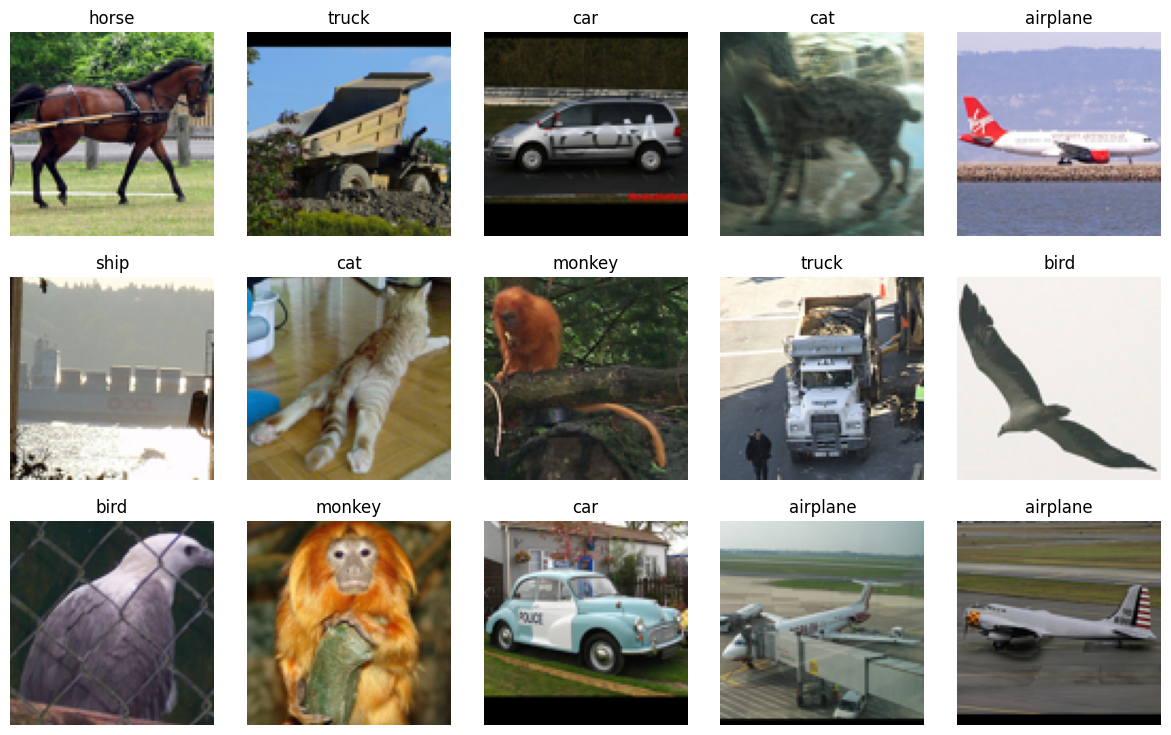

In [9]:
import random
import matplotlib.pyplot as plt

class_names = ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']

r, c = 3, 5
plt.figure(figsize=(c*3, r*3))
for row in range(r):
    for col in range(c):
        index = c*row + col
        plt.subplot(r, c, index + 1)
        ix = random.randint(0, len(train)-1)
        img, label = train[ix]
        img_show = (img + 1) / 2
        plt.imshow(img_show.permute(1, 2, 0).cpu())
        plt.axis('off')
        label_idx = int(label) if isinstance(label, torch.Tensor) else label
        plt.title(class_names[label_idx])
plt.subplots_adjust(wspace=0.1, hspace=0.2)
plt.show()

El objetivo es entrenar una GAN que sintetice imágenes similares a las del conjunto de datos a partir de vectores de ruido aleatorio. Para esto necesitamos un **generador** y un **discriminador**. Empezaremos con una arquitectura fundamental usando Perceptrón Multicapa (MLP) para ambas redes antes de pasar a arquitecturas más avanzadas.

In [10]:
import torch.nn as nn

def block(n_in, n_out):
  return nn.Sequential(
      nn.Linear(n_in, n_out),
      nn.BatchNorm1d(n_out),
      nn.LeakyReLU(0.2, inplace=True)
  )

class MLP(nn.Module):
  def __init__(self, input_size, output_size):
    super().__init__()
    self.input_size = input_size
    self.fc1 = block(input_size, 512)
    self.fc2 = block(512, 256)
    self.fc3 = nn.Linear(256, output_size)

  def forward(self, x):
    x = self.fc1(x)
    x = self.fc2(x)
    x = self.fc3(x)
    return x


In [11]:
MLP


__main__.MLP

Nuestra arquitectura MLP se compone de tres capas densas conectadas (cada una seguida de activación ReLU). Según el número de entradas y salidas, definimos los distintos modelos. Por ejemplo, el generador recibirá un vector de 100 valores aleatorios y producirá como salida un tensor de 120x120x3 elementos (equivalentes a una imagen del conjunto de datos).

In [12]:
n_in, n_out = 100, 96*96*3
generator = MLP(n_in, n_out).to(device)


In [13]:
output = generator(torch.randn(64, 100).to(device))
output.shape


torch.Size([64, 27648])

Obviamente, nuestro generador inicializado genera imágenes aleatorias que en nada se parecen a las reales.

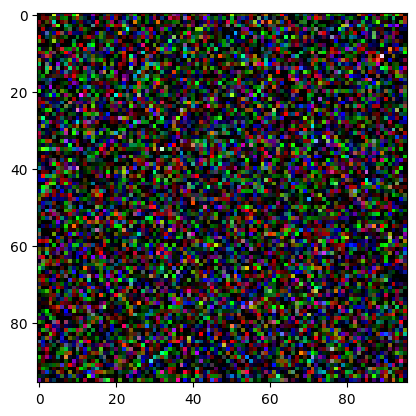

In [14]:
plt.imshow(output[0].reshape(3, 96, 96).permute(1, 2, 0).detach().cpu())
plt.show()

El discriminador, por otro lado, recibirá a la entrada una imagen (96 x 96 valores) y a la salida nos dará una clasificación binaria (real o falso).

In [15]:
discriminator = MLP(96*96*3, 1).to(device)
output = discriminator(torch.randn(64, 96*96*3).to(device))
output.shape


torch.Size([64, 1])

In [16]:
from fastprogress import master_bar, progress_bar

def fit(g, d, dataloader, epochs=30, crit=None):
  g.to(device)
  d.to(device)
  lr_gen  = 2e-4
  lr_disc = 2e-4
  g_optimizer = torch.optim.Adam(g.parameters(), lr=lr_gen,  betas=(0.5, 0.999))
  d_optimizer = torch.optim.Adam(d.parameters(), lr=lr_disc, betas=(0.5, 0.999))
  crit = nn.BCEWithLogitsLoss() if crit is None else crit
  g_loss, d_loss = [], []
  mb = master_bar(range(1, epochs+1))
  hist = {'g_loss': [], 'd_loss': []}

  for epoch in mb:
    for X, y in progress_bar(dataloader, parent=mb):
      X      = X.to(device)
      X_flat = X.view(X.size(0), -1)
      batch_size = X.size(0)

      g.eval(); d.train()
      noise            = torch.randn((batch_size, g.input_size)).to(device)
      generated_images = g(noise).detach()
      d_input = torch.cat([generated_images, X_flat])
      d_gt    = torch.cat([
          torch.zeros(batch_size, 1),
          torch.full((batch_size, 1), 0.9)
      ]).to(device)

      d_optimizer.zero_grad()
      d_l = crit(d(d_input), d_gt)
      d_l.backward()
      torch.nn.utils.clip_grad_norm_(d.parameters(), 1.0)
      d_optimizer.step()
      d_loss.append(d_l.item())

      g.train(); d.eval()
      noise            = torch.randn((batch_size, g.input_size)).to(device)
      generated_images = g(noise)
      g_gt  = torch.ones(batch_size, 1).to(device)

      g_optimizer.zero_grad()
      g_l = crit(d(generated_images), g_gt)
      g_l.backward()
      torch.nn.utils.clip_grad_norm_(g.parameters(), 1.0)
      g_optimizer.step()
      g_loss.append(g_l.item())

      mb.child.comment = f'g_loss {np.mean(g_loss[-100:]):.5f} d_loss {np.mean(d_loss[-100:]):.5f}'

    epoch_g_loss = np.mean(g_loss[-100:])
    epoch_d_loss = np.mean(d_loss[-100:])
    mb.write(f'Epoch {epoch}/{epochs} g_loss {epoch_g_loss:.5f} d_loss {epoch_d_loss:.5f}')
    hist['g_loss'].append(epoch_g_loss)
    hist['d_loss'].append(epoch_d_loss)

    if epoch > 50:
      if epoch_d_loss < 0.05 and epoch_g_loss > 1.0:
        mb.write(f'Early stop: discriminador dominante en época {epoch}')
        break
  return hist

In [17]:
hist = fit(generator, discriminator, dataloader, epochs=150)

<div><p>Epoch 1/150 g_loss 2.19554 d_loss 0.24296</p><p>Epoch 2/150 g_loss 3.04451 d_loss 0.22472</p><p>Epoch 3/150 g_loss 3.38354 d_loss 0.20985</p><p>Epoch 4/150 g_loss 4.00721 d_loss 0.20285</p><p>Epoch 5/150 g_loss 4.50810 d_loss 0.19535</p><p>Epoch 6/150 g_loss 4.43337 d_loss 0.19171</p><p>Epoch 7/150 g_loss 4.59822 d_loss 0.18926</p><p>Epoch 8/150 g_loss 4.35479 d_loss 0.18026</p><p>Epoch 9/150 g_loss 6.34626 d_loss 0.17780</p><p>Epoch 10/150 g_loss 6.16248 d_loss 0.17649</p><p>Epoch 11/150 g_loss 4.96752 d_loss 0.17883</p><p>Epoch 12/150 g_loss 4.49923 d_loss 0.18009</p><p>Epoch 13/150 g_loss 4.53653 d_loss 0.17842</p><p>Epoch 14/150 g_loss 4.44068 d_loss 0.18113</p><p>Epoch 15/150 g_loss 3.72691 d_loss 0.17614</p><p>Epoch 16/150 g_loss 3.80534 d_loss 0.17017</p><p>Epoch 17/150 g_loss 5.17765 d_loss 0.16883</p><p>Epoch 18/150 g_loss 5.24212 d_loss 0.16909</p><p>Epoch 19/150 g_loss 4.64458 d_loss 0.16882</p><p>Epoch 20/150 g_loss 3.99164 d_loss 0.16763</p><p>Epoch 21/150 g_loss 4.57327 d_loss 0.17198</p><p>Epoch 22/150 g_loss 4.45050 d_loss 0.17387</p><p>Epoch 23/150 g_loss 4.67354 d_loss 0.17320</p><p>Epoch 24/150 g_loss 4.59041 d_loss 0.17093</p><p>Epoch 25/150 g_loss 4.33818 d_loss 0.17244</p><p>Epoch 26/150 g_loss 4.20519 d_loss 0.17133</p><p>Epoch 27/150 g_loss 4.22340 d_loss 0.16626</p><p>Epoch 28/150 g_loss 4.63016 d_loss 0.16707</p><p>Epoch 29/150 g_loss 4.81545 d_loss 0.17222</p><p>Epoch 30/150 g_loss 5.49023 d_loss 0.17418</p><p>Epoch 31/150 g_loss 4.71543 d_loss 0.17030</p><p>Epoch 32/150 g_loss 4.48441 d_loss 0.17039</p><p>Epoch 33/150 g_loss 5.23344 d_loss 0.17382</p><p>Epoch 34/150 g_loss 7.06919 d_loss 0.17707</p><p>Epoch 35/150 g_loss 7.15108 d_loss 0.17619</p><p>Epoch 36/150 g_loss 6.81950 d_loss 0.17713</p><p>Epoch 37/150 g_loss 6.81113 d_loss 0.17979</p><p>Epoch 38/150 g_loss 6.70951 d_loss 0.17952</p><p>Epoch 39/150 g_loss 6.18521 d_loss 0.18427</p><p>Epoch 40/150 g_loss 6.33334 d_loss 0.18476</p><p>Epoch 41/150 g_loss 6.21098 d_loss 0.18248</p><p>Epoch 42/150 g_loss 6.20738 d_loss 0.18485</p><p>Epoch 43/150 g_loss 5.49553 d_loss 0.18683</p><p>Epoch 44/150 g_loss 5.75540 d_loss 0.18970</p><p>Epoch 45/150 g_loss 5.52046 d_loss 0.19043</p><p>Epoch 46/150 g_loss 5.60189 d_loss 0.19649</p><p>Epoch 47/150 g_loss 5.10160 d_loss 0.19863</p><p>Epoch 48/150 g_loss 4.91337 d_loss 0.20837</p><p>Epoch 49/150 g_loss 4.43345 d_loss 0.21310</p><p>Epoch 50/150 g_loss 4.12300 d_loss 0.21497</p><p>Epoch 51/150 g_loss 3.83712 d_loss 0.21207</p><p>Epoch 52/150 g_loss 3.74508 d_loss 0.21202</p><p>Epoch 53/150 g_loss 3.82400 d_loss 0.21156</p><p>Epoch 54/150 g_loss 3.36172 d_loss 0.21111</p><p>Epoch 55/150 g_loss 3.32846 d_loss 0.22061</p><p>Epoch 56/150 g_loss 3.49614 d_loss 0.21709</p><p>Epoch 57/150 g_loss 3.25274 d_loss 0.21094</p><p>Epoch 58/150 g_loss 3.13915 d_loss 0.21711</p><p>Epoch 59/150 g_loss 3.15107 d_loss 0.22011</p><p>Epoch 60/150 g_loss 3.04501 d_loss 0.22100</p><p>Epoch 61/150 g_loss 2.53638 d_loss 0.22158</p><p>Epoch 62/150 g_loss 2.51427 d_loss 0.22054</p><p>Epoch 63/150 g_loss 2.84518 d_loss 0.21842</p><p>Epoch 64/150 g_loss 2.65899 d_loss 0.21982</p><p>Epoch 65/150 g_loss 2.54209 d_loss 0.22004</p><p>Epoch 66/150 g_loss 2.76547 d_loss 0.22218</p><p>Epoch 67/150 g_loss 2.80182 d_loss 0.21971</p><p>Epoch 68/150 g_loss 2.71505 d_loss 0.22200</p><p>Epoch 69/150 g_loss 2.71672 d_loss 0.21770</p><p>Epoch 70/150 g_loss 3.05090 d_loss 0.21700</p><p>Epoch 71/150 g_loss 2.82419 d_loss 0.22246</p><p>Epoch 72/150 g_loss 2.49019 d_loss 0.23462</p><p>Epoch 73/150 g_loss 2.67202 d_loss 0.23296</p><p>Epoch 74/150 g_loss 2.85011 d_loss 0.22475</p><p>Epoch 75/150 g_loss 2.52178 d_loss 0.22842</p><p>Epoch 76/150 g_loss 2.65519 d_loss 0.23382</p><p>Epoch 77/150 g_loss 2.62037 d_loss 0.23070</p><p>Epoch 78/150 g_loss 2.66653 d_loss 0.23556</p><p>Epoch 79/150 g_loss 2.24910 d_loss 0.23795</p><p>Epoch 80/150 g_loss 2.39714 d_loss 0.23867</p><p>Epoch 81/150 g_loss 2.51830 d_loss 0.23238</p><p>Epoch 82/150 g_loss 2.49377 d_lo

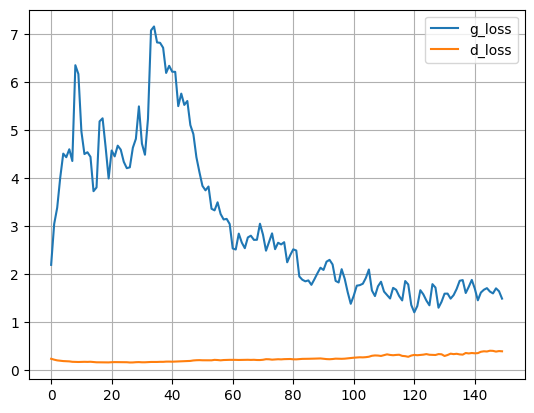

In [18]:
import pandas as pd

df = pd.DataFrame(hist)
df.plot(grid=True)
plt.show()


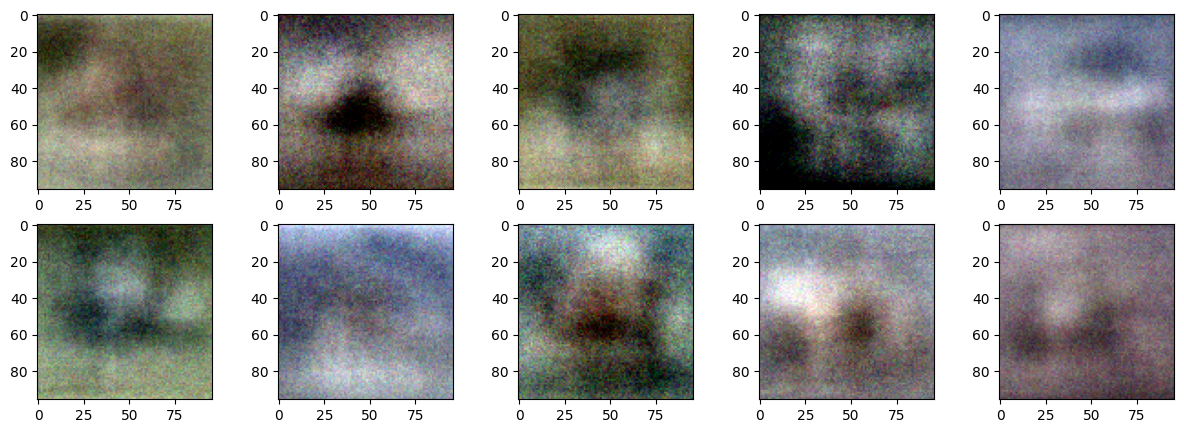

In [19]:
generator.eval()
with torch.no_grad():
  noise = torch.randn((10, generator.input_size)).to(device)
  generated_images = generator(noise)
  fig, axs = plt.subplots(2,5,figsize=(15,5))
  i = 0
  for ax in axs:
    for _ax in ax:
      img = generated_images[i].view(3, 96, 96).permute(1, 2, 0).cpu()
      img = (img + 1) / 2
      _ax.imshow(img.clamp(0, 1))
      i+=1
  plt.show()

Aunque hemos construido correctamente el circuito de entrenamiento de una GAN, nuestro modelo elemental no genera imágenes de calidad satisfactoria. Para lograr resultados superiores se requiere una arquitectura especializada para procesamiento de imágenes: las redes convolucionales.

## Arquitecturas Convolucionales Profundas: DCGANs

Las redes GANs convolucionales profundas (DCGANs) integran arquitecturas convolucionales para lograr generadores de mayor capacidad. En este enfoque, el generador y discriminador requieren diseños especializados distintos.

![](https://gluon.mxnet.io/_images/dcgan.png)

El generador comienza con un vector de 100 valores aleatorios al cual se aplican sucesivamente capas de convolución transpuesta (que expanden progresivamente el tamaño de los mapas de características, similar a técnicas de segmentación semántica) hasta producir la imagen final.


In [50]:
import torch.nn as nn


class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_size = 100
        self.inp = nn.Sequential(
            nn.Linear(self.input_size, 6*6*512),
            nn.BatchNorm1d(6*6*512),
            nn.ReLU(True),
        )
        self.main = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, 4, stride=2, padding=1, bias=False),
            nn.Tanh()

        )

    def forward(self, x):
        x = self.inp(x)
        x = x.view(-1, 512, 6, 6)
        x = self.main(x)

        return x

In [51]:
generator = Generator().to(device)
output = generator(torch.randn(128, 100).to(device))
output.shape

torch.Size([128, 3, 96, 96])

La capa final del generador utiliza activación tanh, produciendo valores en el rango [-1, 1]. Por esta razón, normalizamos las imágenes del conjunto de datos usando la misma escala.

In [52]:
train = STL10Dataset('./stl10_matlab', mat_file='train.mat', image_size=96)
len(train)

Dataset MATLAB cargado desde train.mat:
  - 5000 imágenes de shape (5000, 96, 96, 3)
  - Clases: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


5000

In [53]:
img, label = train[0]
img.shape, img.dtype, img.max(), img.min()


(torch.Size([3, 96, 96]), torch.float32, tensor(1.), tensor(-1.))

In [54]:
import torch
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

In [55]:
dataloader = torch.utils.data.DataLoader(train, batch_size=128, shuffle=True)

imgs, labels = next(iter(dataloader))
imgs.shape, labels.shape

(torch.Size([128, 3, 96, 96]), torch.Size([128]))

Para el discriminador, emplearemos una red neuronal convolucional estándar, similar a la utilizada en tareas de reconocimiento de objetos.

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(3, 64, 4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.out = nn.Linear(512*6*6, 1)

    def forward(self, x):
        x = self.main(x)
        x = x.view(x.size(0), -1)
        return self.out(x)

In [57]:
discriminator = Discriminator().to(device)
output = discriminator(torch.randn(128, 3, 96, 96).to(device))
output.shape

torch.Size([128, 1])

In [ ]:
def fit(g, d, dataloader, epochs=150, crit=None, n_critic=1):
    g.to(device); d.to(device)
    g_optimizer = torch.optim.Adam(g.parameters(), lr=2e-4, betas=(0.5, 0.999))
    d_optimizer = torch.optim.Adam(d.parameters(), lr=1e-4, betas=(0.5, 0.999))
    g_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(g_optimizer, T_max=epochs, eta_min=1e-5)
    d_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(d_optimizer, T_max=epochs, eta_min=1e-5)
    crit = nn.BCEWithLogitsLoss() if crit is None else crit
    hist = {'g_loss': [], 'd_loss': []}
    mb = master_bar(range(1, epochs+1))

    for epoch in mb:
        epoch_g, epoch_d = [], []

        for X, _ in progress_bar(dataloader, parent=mb):
            X = X.to(device)          
            batch_size = X.size(0)

            g.eval(); d.train()
            for _ in range(n_critic):
                noise = torch.randn(batch_size, g.input_size, device=device)
                fake  = g(noise).detach()                          

                real_lbl = torch.full((batch_size, 1), 0.9, device=device)
                fake_lbl = torch.zeros(batch_size, 1, device=device)

                d_optimizer.zero_grad()
                d_l = crit(d(X), real_lbl) + crit(d(fake), fake_lbl)
                d_l.backward()
                torch.nn.utils.clip_grad_norm_(d.parameters(), 1.0)
                d_optimizer.step()
            epoch_d.append(d_l.item())

            g.train(); d.eval()
            noise = torch.randn(batch_size, g.input_size, device=device)
            fake  = g(noise)                                      

            g_optimizer.zero_grad()
            g_l = crit(d(fake), torch.ones(batch_size, 1, device=device))
            g_l.backward()
            torch.nn.utils.clip_grad_norm_(g.parameters(), 1.0)
            g_optimizer.step()
            epoch_g.append(g_l.item())

            mb.child.comment = f'g={np.mean(epoch_g):.4f} d={np.mean(epoch_d):.4f}'

        g_scheduler.step(); d_scheduler.step()
        eg, ed = np.mean(epoch_g), np.mean(epoch_d)
        hist['g_loss'].append(eg); hist['d_loss'].append(ed)
        mb.write(f'Epoch {epoch}/{epochs} | g={eg:.4f} d={ed:.4f}')

    return hist

Ahora aplicamos el mismo procedimiento de entrenamiento para obtener un generador de mayor poder expresivo con arquitectura DCGAN. **Ajusta parámetros si necesario**: aumenta `epochs` para mejor convergencia

In [ ]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

hist = fit(generator, discriminator, dataloader, epochs=60, n_critic=1)

<div><div><progress max="60" value="15"></progress> 25.00% [15/60 03:57&lt;11:52]</div><div><p>Epoch 1/60 | g=0.1992 d=0.4149</p><p>Epoch 2/60 | g=0.0034 d=0.3330</p><p>Epoch 3/60 | g=0.0022 d=0.3284</p><p>Epoch 4/60 | g=0.0016 d=0.3274</p><p>Epoch 5/60 | g=0.0017 d=0.3274</p><p>Epoch 6/60 | g=0.0017 d=0.3268</p><p>Epoch 7/60 | g=0.0017 d=0.3271</p><p>Epoch 8/60 | g=0.0016 d=0.3264</p><p>Epoch 9/60 | g=0.0015 d=0.3262</p><p>Epoch 10/60 | g=0.0017 d=0.3265</p><p>Epoch 11/60 | g=0.0016 d=0.3263</p><p>Epoch 12/60 | g=0.0018 d=0.3261</p><p>Epoch 13/60 | g=0.0019 d=0.3259</p><p>Epoch 14/60 | g=0.0020 d=0.3258</p><p>Epoch 15/60 | g=0.0021 d=0.3259</p></div><div><progress max="40" value="12"></progress> 30.00% [12/40 00:04&lt;00:11... g=0.0023 d=0.3263]</div></div>

In [ ]:
df = pd.DataFrame(hist)
df.plot(grid=True)
plt.show()

In [ ]:
generator.eval()
with torch.no_grad():
  noise = torch.randn((10, generator.input_size)).to(device)
  generated_images = generator(noise)
  fig, axs = plt.subplots(2,5,figsize=(15,5))
  i = 0
  for ax in axs:
    for _ax in ax:
      img = generated_images[i].view(3, 96, 96).permute(1, 2, 0).cpu()
      img = (img + 1) / 2
      _ax.imshow(img.clamp(0, 1))
      i+=1
  plt.show()

En este caso, las imágenes producidas presentan una mejora notable en comparación con las generadas por la arquitectura simple, aunque todavía existe espacio para refinamientos adicionales.

## Resumen y Reflexión

En este análisis hemos explorado los fundamentos de las redes adversariales generativas (GANs), una clase extraordinaria de arquitecturas neuronales capaces de sintetizar datos realistas basándose en patrones del conjunto de entrenamiento, con énfasis en síntesis de imágenes. La estructura subyacente comprende dos agentes en competencia: el generador sintetiza imágenes a partir de vectores latentes de ruido, mientras que el discriminador intenta clasificar entre muestras auténticas del conjunto de datos y productos artificiales del generador. Una vez completado el entrenamiento, el discriminador se descarta y el generador se convierte en una herramienta versátil para crear imágenes sintéticas realistas. Estas arquitecturas encuentran aplicación en numerosos campos: síntesis de caras inexistentes, restauración y colorización de fotografías históricas, generación de objetos a partir de descripciones textuales, producción de videos sintéticos realistas, y la controvertida tecnología de videos deepfake, entre otros.